In [166]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [167]:
df = pd.read_csv('../Lab1/time_series.csv')
data = df['value']
values = data.values

In [168]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(values.reshape(-1,1))

In [169]:
n = 30
train_size = int(len(scaled_values) * 0.9)
train_data = scaled_values[0:int(train_size), :]

X = [train_data[i-n:i, 0] for i in range(n, len(train_data))]
y = train_data[n:, 0]

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = np.reshape(
    X_train,
    (X_train.shape[0], X_train.shape[1], 1)
)

In [170]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(n, 1)),
    LSTM(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, batch_size=1, epochs=1)

870/870 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0012


Метрики:

In [171]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

test_data = scaled_values[train_size - n: , :]

x_test = []
y_test = values[train_size:]
for i in range(n, len(test_data)):
    x_test.append(test_data[i-n:i, 0])
    
x_test = np.array(x_test)

x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))
 
predictions = model.predict(x_test)
pred = scaler.inverse_transform(predictions)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"MAE  -  {mae}")
print(f"MSE  -  {mse}")
print(f"RMSE  -  {rmse}")
print(f"MAPE  -  {mape}")
print(f"R2  -  {r2}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
MAE  -  5.56470837345129
MSE  -  46.25083763352598
RMSE  -  6.800796838130513
MAPE  -  0.00836949756813985
R2  -  0.967852357068202


LSTM хорошо прогнозирует ряд, поскольку R2 имеет высокое значение, а MAE и RMSE небольшие. MAPE = 0.008, что говорит о высокой точности

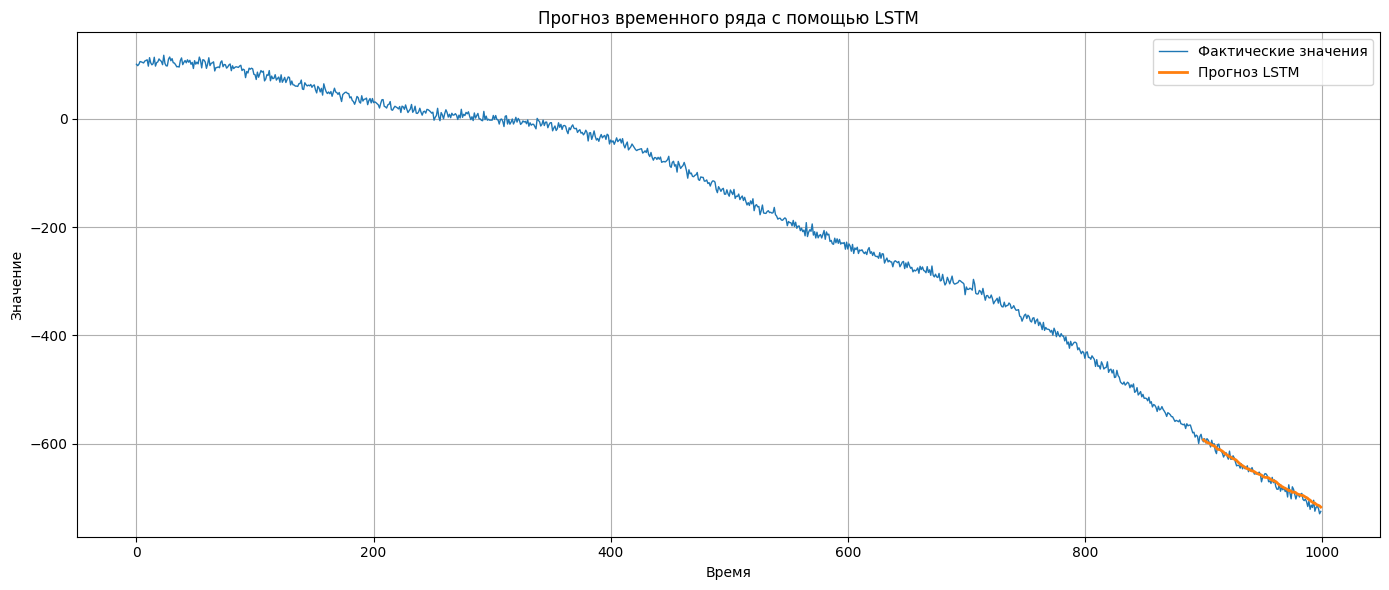

In [172]:
train_index = np.arange(train_size)
test_index = np.arange(train_size, train_size + len(pred))

plt.figure(figsize=(14, 6))

plt.plot(values, label="Фактические значения", linewidth=1)

plt.plot(test_index, pred, label="Прогноз LSTM", linewidth=2)


plt.title("Прогноз временного ряда с помощью LSTM")
plt.xlabel("Время")
plt.ylabel("Значение")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

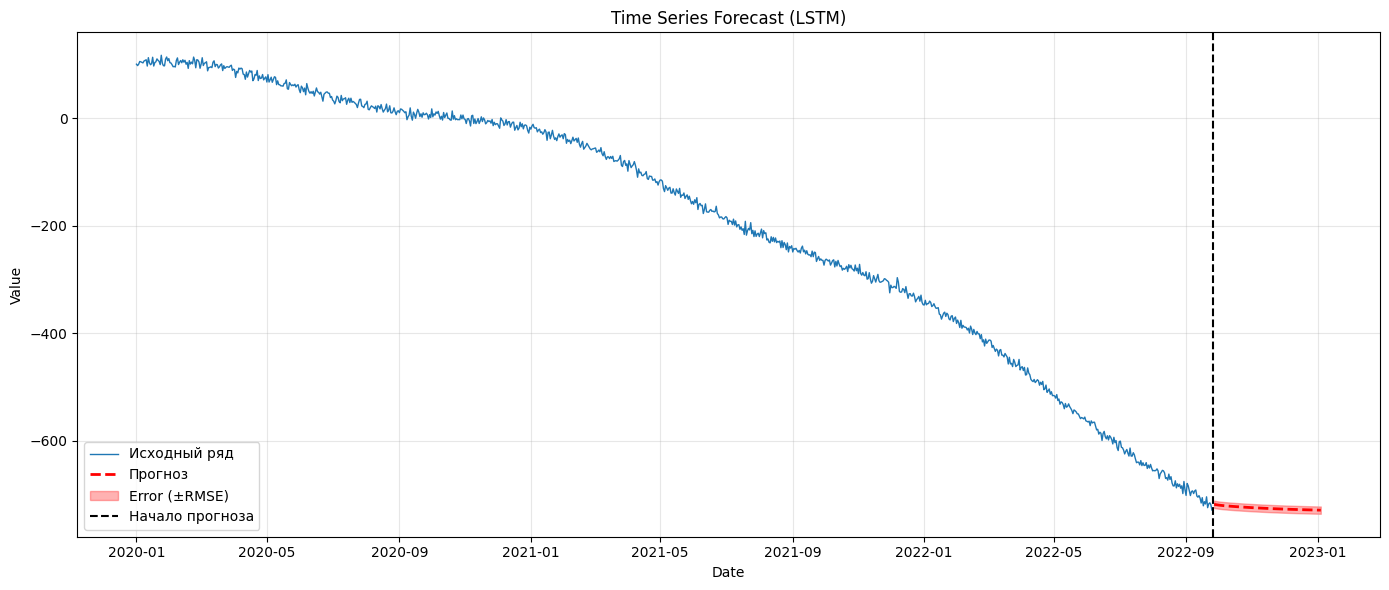

In [173]:
n_future = 100 

last_sequence = scaled_values[-n:].reshape(n,)

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(n_future):
    x_input = current_sequence.reshape(1, n, 1)
    next_pred = model.predict(x_input, verbose=0)
    
    future_predictions.append(next_pred[0, 0])
    
    current_sequence = np.roll(current_sequence, -1)
    current_sequence[-1] = next_pred[0, 0]

future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions).flatten()

df['date'] = pd.to_datetime(df['date'])

last_date = df.iloc[-1]['date']

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=n_future,
    freq='D'
)


plt.figure(figsize=(14, 6))

plt.plot(df['date'], df['value'],
         label='Исходный ряд', linewidth=1)

plt.plot(future_dates, future_predictions,
         label='Прогноз', color="red", linewidth=2, linestyle='--')

plt.fill_between(
    future_dates,
    future_predictions - rmse,
    future_predictions + rmse,
    label='Error (±RMSE)',
    color="red",
    alpha=0.3
)

plt.axvline(
    x=last_date,
    linestyle='--',
    label='Начало прогноза',
    color="black"
)

plt.title('Time Series Forecast (LSTM)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

LSTM заметно отклоняется от ожидаемого прогноза. Использование статистического метода позволяет получить устойчивый прогноз для этой задачи